In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install transformers datasets accelerate
!pip install optuna optuna-dashboard
!pip install plotly nbformat
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 7.8 MB/s eta 0:00:0000:01m0:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 5.4 MB/s eta 0:00:00


In [2]:
!pip install pandas numpy torch transformers datasets evaluate optuna scikit-learn matplotlib seaborn plotly tqdm

In [3]:
# Standard Libraries
import os
import time
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import evaluate
import optuna


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import optuna.visualization as vis
import plotly.io as pio
import plotly.graph_objects as go


# Transformers (RoBERTa)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)


# Model Selection
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)


# Utilities
from scipy.special import softmax

In [4]:
# Load dataset
df = pd.read_csv('phishing_email_corpus - phishing_email_corpus.csv') 

# Clean Data
initial_count = len(df)
df.drop_duplicates(inplace=True)
df.dropna(subset=['email', 'label'], inplace=True)
df = df.drop(columns=["source"])
print(f"Removed {initial_count - len(df)} duplicate/null rows.")
print(f"Total Clean Emails: {df.shape[0]}")

# Check Class Balance
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

df.head()

Removed 250 duplicate/null rows.
Total Clean Emails: 44470

Class Distribution:
label
1    55.52%
0    44.48%
Name: proportion, dtype: str


,email,label
1,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1
2,Your two incoming mails were placed on pending...,1
3,Password will expire in 3 days. Click Here To ...,1
4,"To ensure delivery to your inbox, please add U...",1
5,"PayPal Secure Dear Client, ...",1


In [5]:
# 80%-20% Train-Test Data Split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['email'].tolist(),
    df['label'].tolist(),
    test_size=0.2,           
    random_state=42,
    stratify=df['label']     
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

train_encodings = tokenizer(train_texts, truncation=True)
test_encodings  = tokenizer(test_texts, truncation=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [7]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
test_dataset  = EmailDataset(test_encodings, test_labels)

# Dynamic Padding (Instead of traditional static padding with padding=True when calling the tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [8]:
def evaluate_model(eval_pred, start_time=None):

    logits, labels = eval_pred
    
    # Logits to probabilities
    predictions = np.argmax(logits, axis=-1)
    
    # Softmax for ROC-AUC
    probs = softmax(logits, axis=-1)[:, 1] 
    
    # Standard metrics
    metrics = {
        'accuracy':  accuracy_score(labels, predictions),
        'f1':        f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro'),
        'recall':    recall_score(labels, predictions, average='macro'),
        'roc_auc':   roc_auc_score(labels, probs)
    }
    
    # Time Metrics
    if start_time is not None:
        metrics['duration'] = time.time() - start_time
    
    return metrics

In [9]:
def objective(trial):
    
    # Parameters
    params = {
        "learning_rate":    trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "batch_size":       trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32]),
        "epochs":           trial.suggest_int("num_train_epochs", 2, 4),
        "warmup_steps":     trial.suggest_int("warmup_steps", 0, 500),
        "adam_epsilon":     trial.suggest_float("adam_epsilon", 1e-9, 1e-6, log=True),
        "weight_decay":     trial.suggest_float("weight_decay", 0.01, 0.1)
    }

    # Training Arguments
    training_args = TrainingArguments(
        output_dir="./optuna_temp",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=params["epochs"],
        warmup_steps=params["warmup_steps"],
        adam_epsilon=params["adam_epsilon"],
        weight_decay=params["weight_decay"],
        report_to="none",
        disable_tqdm=True,
        fp16=torch.cuda.is_available() 
    )

    model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=evaluate_model, 
        data_collator=data_collator,
    )

    # Execution
    trainer.train()
    eval_results = trainer.evaluate()
    
    # Target metric for Optuna to maximize
    return eval_results["eval_f1"]

In [10]:
# Study
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=3)

[I 2026-03-03 00:22:43,342] A new study created in memory with name: no-name-46af3c1b-3b49-41c2-9f12-921131511a59


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.2263', 'grad_norm': '0.0132', 'learning_rate': '2.484e-05', 'epoch': '0.1124'}
{'loss': '0.114', 'grad_norm': '0.01807', 'learning_rate': '2.412e-05', 'epoch': '0.2249'}
{'loss': '0.06158', 'grad_norm': '0.04955', 'learning_rate': '2.34e-05', 'epoch': '0.3373'}
{'loss': '0.05831', 'grad_norm': '64.55', 'learning_rate': '2.268e-05', 'epoch': '0.4497'}
{'loss': '0.05176', 'grad_norm': '0.002459', 'learning_rate': '2.197e-05', 'epoch': '0.5622'}
{'loss': '0.05242', 'grad_norm': '0.008571', 'learning_rate': '2.125e-05', 'epoch': '0.6746'}
{'loss': '0.05493', 'grad_norm': '0.003592', 'learning_rate': '2.053e-05', 'epoch': '0.787'}
{'loss': '0.04166', 'grad_norm': '38.59', 'learning_rate': '1.981e-05', 'epoch': '0.8995'}
{'eval_loss': '0.03804', 'eval_accuracy': '0.993', 'eval_f1': '0.993', 'eval_precision': '0.9924', 'eval_recall': '0.9935', 'eval_roc_auc': '0.9998', 'eval_runtime': '18.21', 'eval_samples_per_second': '488.3', 'eval_steps_per_second': '61.05', 'epoch': '1'}
{'lo

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1444', 'grad_norm': '0.05792', 'learning_rate': '2.619e-05', 'epoch': '0.4496'}
{'loss': '0.04261', 'grad_norm': '21.04', 'learning_rate': '2.287e-05', 'epoch': '0.8993'}
{'eval_loss': '0.1119', 'eval_accuracy': '0.9785', 'eval_f1': '0.9784', 'eval_precision': '0.977', 'eval_recall': '0.9806', 'eval_roc_auc': '0.9998', 'eval_runtime': '11.6', 'eval_samples_per_second': '766.5', 'eval_steps_per_second': '23.96', 'epoch': '1'}
{'loss': '0.01547', 'grad_norm': '6.593', 'learning_rate': '1.956e-05', 'epoch': '1.349'}
{'loss': '0.0118', 'grad_norm': '0.5518', 'learning_rate': '1.624e-05', 'epoch': '1.799'}
{'eval_loss': '0.009646', 'eval_accuracy': '0.9979', 'eval_f1': '0.9978', 'eval_precision': '0.9977', 'eval_recall': '0.998', 'eval_roc_auc': '1', 'eval_runtime': '11.66', 'eval_samples_per_second': '762.7', 'eval_steps_per_second': '23.84', 'epoch': '2'}
{'loss': '0.006047', 'grad_norm': '0.001661', 'learning_rate': '1.293e-05', 'epoch': '2.248'}
{'loss': '0.00398', 'grad_nor

[I 2026-03-03 00:57:13,563] Trial 2 finished with value: 0.998065349345782 and parameters: {'learning_rate': 2.7768678256254338e-05, 'per_device_train_batch_size': 32, 'num_train_epochs': 4, 'warmup_steps': 261, 'adam_epsilon': 7.458002258491154e-09, 'weight_decay': 0.027909234638668054}. Best is trial 2 with value: 0.998065349345782.


{'eval_loss': '0.01148', 'eval_accuracy': '0.9981', 'eval_f1': '0.9981', 'eval_precision': '0.998', 'eval_recall': '0.9982', 'eval_roc_auc': '1', 'eval_runtime': '11.72', 'eval_samples_per_second': '759', 'eval_steps_per_second': '23.72', 'epoch': '4'}


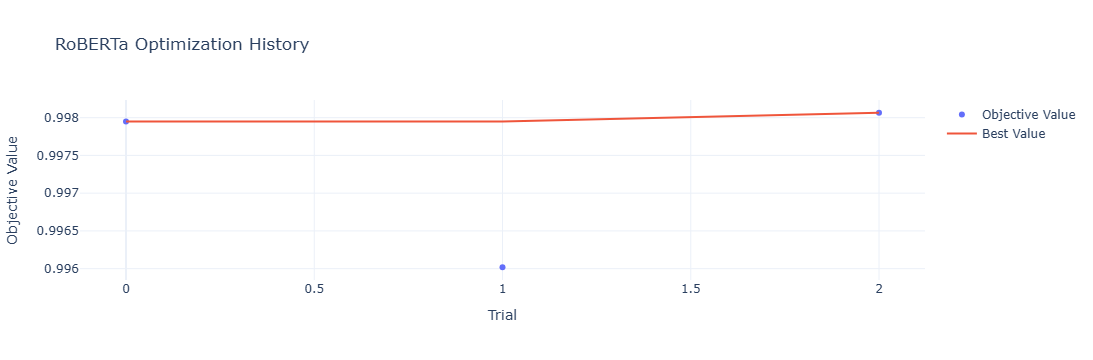

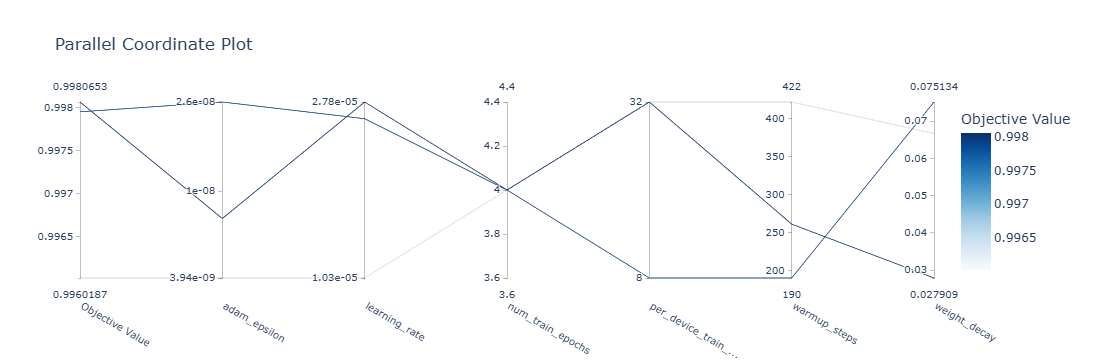

In [11]:
# Optimization History (F1 improvements)
fig_history = vis.plot_optimization_history(study)
fig_history.update_layout(title="RoBERTa Optimization History", template="plotly_white")
fig_history.show()

#This didnt work for 20 entries but for all the dataset it should so uncomment it

# Hyperparameter Importance
#fig_importance = vis.plot_param_importances(study)
#fig_importance.update_layout(title="RoBERTa Hyperparameter Importance", template="plotly_white")
#fig_importance.show()

# Parallel Coordinate Plot (Relationship between parameters and F1)
fig_parallel = vis.plot_parallel_coordinate(study)
fig_parallel.show()

In [12]:
best_params = study.best_params
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

train_texts_np = np.array(train_texts)
train_labels_np = np.array(train_labels)

fold_results = []

# Starified 5-Fold CV
for fold, (train_idx, val_idx) in enumerate(skf.split(train_texts_np, train_labels_np)):
    print(f"\n--- Training Fold {fold + 1}/{n_folds} ---")
    
    fold_train_texts = train_texts_np[train_idx].tolist()
    fold_val_texts   = train_texts_np[val_idx].tolist()
    fold_train_labels = train_labels_np[train_idx].tolist()
    fold_val_labels   = train_labels_np[val_idx].tolist()
    
    train_enc = tokenizer(fold_train_texts, truncation=True, padding=True)
    val_enc   = tokenizer(fold_val_texts, truncation=True, padding=True)
    
    fold_train_ds = EmailDataset(train_enc, fold_train_labels)
    fold_val_ds   = EmailDataset(val_enc, fold_val_labels)
    
    model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
    
    args = TrainingArguments(
        output_dir=f"./fold_{fold}",
        **best_params, # automatically inject our best hyperparameters (LR, batch size, etc.) from the study 
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        disable_tqdm=True
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=fold_train_ds,
        eval_dataset=fold_val_ds,
        compute_metrics=evaluate_model,
        data_collator=data_collator
    )
    
    # Train
    trainer.train()
    
    # Evaluate Fold
    eval_res = trainer.evaluate()
    fold_results.append(eval_res)
    # print(f"Fold {fold+1} F1: {eval_res['eval_f1']:.4f}")

# 3. Aggregate Results
avg_f1 = np.mean([f['eval_f1'] for f in fold_results])
#print(f"\nAverage CV F1 Score: {avg_f1:.4f}")


--- Training Fold 1/5 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1545', 'grad_norm': '0.3741', 'learning_rate': '2.577e-05', 'epoch': '0.5618'}
{'eval_loss': '0.02074', 'eval_accuracy': '0.9948', 'eval_f1': '0.9947', 'eval_precision': '0.995', 'eval_recall': '0.9944', 'eval_roc_auc': '0.9999', 'eval_runtime': '26.01', 'eval_samples_per_second': '273.6', 'eval_steps_per_second': '34.22', 'epoch': '1'}
{'loss': '0.02958', 'grad_norm': '0.009882', 'learning_rate': '2.156e-05', 'epoch': '1.124'}
{'loss': '0.01812', 'grad_norm': '0.01206', 'learning_rate': '1.735e-05', 'epoch': '1.685'}
{'eval_loss': '0.05553', 'eval_accuracy': '0.9882', 'eval_f1': '0.9881', 'eval_precision': '0.9871', 'eval_recall': '0.9893', 'eval_roc_auc': '0.9999', 'eval_runtime': '26.02', 'eval_samples_per_second': '273.5', 'eval_steps_per_second': '34.2', 'epoch': '2'}
{'loss': '0.008851', 'grad_norm': '0.00383', 'learning_rate': '1.314e-05', 'epoch': '2.247'}
{'loss': '0.003816', 'grad_norm': '0.00107', 'learning_rate': '8.931e-06', 'epoch': '2.809'}
{'eval_loss': '0.0

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1498', 'grad_norm': '16.99', 'learning_rate': '2.577e-05', 'epoch': '0.5618'}
{'eval_loss': '0.0211', 'eval_accuracy': '0.994', 'eval_f1': '0.9939', 'eval_precision': '0.9943', 'eval_recall': '0.9935', 'eval_roc_auc': '0.9998', 'eval_runtime': '25.96', 'eval_samples_per_second': '274.1', 'eval_steps_per_second': '34.29', 'epoch': '1'}
{'loss': '0.03906', 'grad_norm': '12.86', 'learning_rate': '2.156e-05', 'epoch': '1.124'}
{'loss': '0.01404', 'grad_norm': '0.001619', 'learning_rate': '1.735e-05', 'epoch': '1.685'}
{'eval_loss': '0.02291', 'eval_accuracy': '0.9955', 'eval_f1': '0.9954', 'eval_precision': '0.9956', 'eval_recall': '0.9953', 'eval_roc_auc': '0.9999', 'eval_runtime': '26.04', 'eval_samples_per_second': '273.2', 'eval_steps_per_second': '34.17', 'epoch': '2'}
{'loss': '0.008222', 'grad_norm': '0.001126', 'learning_rate': '1.314e-05', 'epoch': '2.247'}
{'loss': '0.003322', 'grad_norm': '0.001825', 'learning_rate': '8.931e-06', 'epoch': '2.809'}
{'eval_loss': '0.01

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1491', 'grad_norm': '9.981', 'learning_rate': '2.577e-05', 'epoch': '0.5618'}
{'eval_loss': '0.07409', 'eval_accuracy': '0.9854', 'eval_f1': '0.9852', 'eval_precision': '0.9842', 'eval_recall': '0.9865', 'eval_roc_auc': '0.9996', 'eval_runtime': '26.07', 'eval_samples_per_second': '272.9', 'eval_steps_per_second': '34.14', 'epoch': '1'}
{'loss': '0.03284', 'grad_norm': '0.003369', 'learning_rate': '2.156e-05', 'epoch': '1.124'}
{'loss': '0.01525', 'grad_norm': '0.001891', 'learning_rate': '1.735e-05', 'epoch': '1.685'}
{'eval_loss': '0.0191', 'eval_accuracy': '0.9954', 'eval_f1': '0.9953', 'eval_precision': '0.9952', 'eval_recall': '0.9954', 'eval_roc_auc': '0.9999', 'eval_runtime': '26.03', 'eval_samples_per_second': '273.4', 'eval_steps_per_second': '34.19', 'epoch': '2'}
{'loss': '0.01272', 'grad_norm': '0.00145', 'learning_rate': '1.314e-05', 'epoch': '2.247'}
{'loss': '0.005414', 'grad_norm': '0.0009824', 'learning_rate': '8.931e-06', 'epoch': '2.809'}
{'eval_loss': '0

In [13]:
winner_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

winner_args = TrainingArguments(
    output_dir="./winner_model",
    **study.best_params,         
    eval_strategy="no",          
    save_strategy="no",
    report_to="none",
    logging_steps=10,
    fp16=torch.cuda.is_available()
)

winner_trainer = Trainer(
    model=winner_model,
    args=winner_args,
    train_dataset=train_dataset, 
    data_collator=data_collator,
)

start_time = time.time()
winner_trainer.train()


test_results = winner_trainer.predict(test_dataset)

# Extract logits and labels for the evaluation function
eval_pred = (test_results.predictions, test_results.label_ids)

# Metrics
final_metrics = evaluate_model(eval_pred, start_time=start_time)
final_metrics['Model'] = "RoBERTa (Final)"
final_metrics['CV_Avg_F1'] = avg_f1 # From your Cross-Validation cell
performance_df = pd.DataFrame([final_metrics])
styled_df = performance_df.style.set_properties(**{
    'text-align': 'right',      
    'font-family': 'monospace',   
}).set_table_styles([{
    'selector': 'th',             
    'props': [('text-align', 'center')]
}]).hide(axis='index')           
display(styled_df)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,0.692385
20,0.697456
30,0.688230
40,0.678622
50,0.666430
60,0.624828
70,0.444982
80,0.173821
90,0.089131
100,0.181762


accuracy,f1,precision,recall,roc_auc,duration,Model,CV_Avg_F1
0.997864,0.997838,0.997727,0.997950,0.999973,530.131641,RoBERTa (Final),0.996643


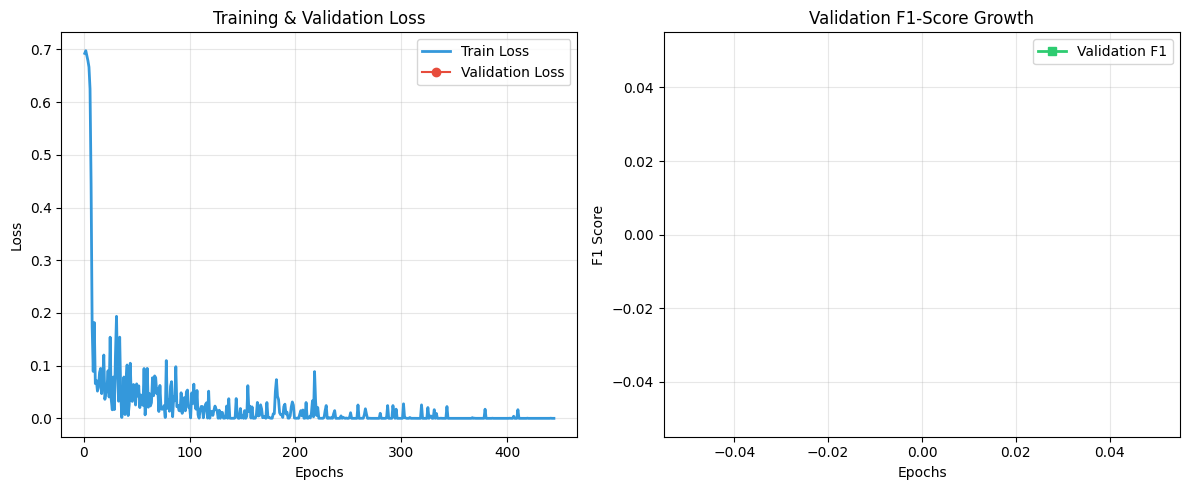

In [14]:
history = winner_trainer.state.log_history

train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_f1 = [log['eval_f1'] for log in history if 'eval_f1' in log]
epochs = [log['epoch'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(epochs, eval_loss, label='Validation Loss', color='#e74c3c', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# F1 Score Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, eval_f1, label='Validation F1', color='#2ecc71', marker='s', linewidth=2)
plt.title('Validation F1-Score Growth')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

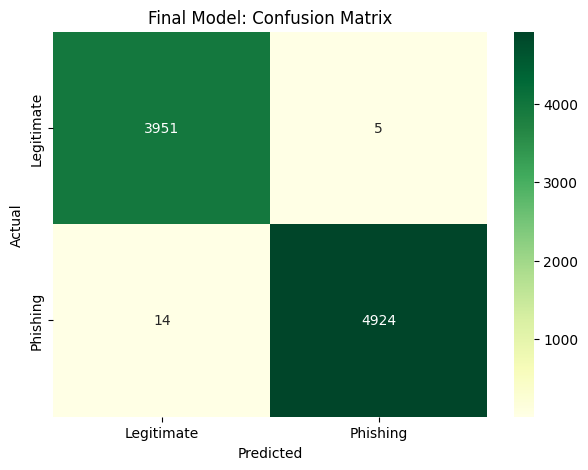


Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3956
    Phishing       1.00      1.00      1.00      4938

    accuracy                           1.00      8894
   macro avg       1.00      1.00      1.00      8894
weighted avg       1.00      1.00      1.00      8894



In [15]:
y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=-1)

# Confusion Matrix
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])
plt.title("Final Model: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))

In [18]:
import re

def preprocess_basic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    return text

def preprocess_extended(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# External Data (SpamAssassin)
df_sa = pd.read_csv(
    'SpamAssasin.csv',
    encoding='latin-1',
    on_bad_lines='skip'
).dropna(subset=['body', 'label'])

df_sa['body_clean'] = df_sa['body'].apply(preprocess_basic).apply(preprocess_extended)

# 2. Re-train the "Best" Model

best_params = study.best_params

final_args = TrainingArguments(
    output_dir="./final_roberta_model",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["per_device_train_batch_size"],
    num_train_epochs=best_params["num_train_epochs"],
    weight_decay=best_params["weight_decay"],
    save_strategy="no",
    report_to="none"
)

final_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset, 
    data_collator=data_collator
)

final_trainer.train()

print("--- External Validation: SpamAssassin ---")

external_encodings = tokenizer(df_sa['body_clean'].tolist(), truncation=True, padding=True)
external_dataset = EmailDataset(external_encodings, df_sa['label'].tolist())
raw_preds = final_trainer.predict(external_dataset)
y_sa_true = df_sa['label'].values
y_sa_pred = np.argmax(raw_preds.predictions, axis=-1)

sa_f1 = f1_score(y_sa_true, y_sa_pred, average='macro')
internal_f1 = study.best_value

print("\nDetailed Classification Report (External):")
print(classification_report(y_sa_true, y_sa_pred, target_names=['Legitimate', 'Phishing']))

print(f"Internal Best CV F1: {internal_f1:.4f}")
print(f"External SpamAssassin F1: {sa_f1:.4f}")
print(f"Performance Gap: {internal_f1 - sa_f1:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.080717
1000,0.035699
1500,0.016227
2000,0.011198
2500,0.005961
3000,0.004478
3500,0.002906
4000,0.000581
